## Adatok betöltése

In [4]:
import pandas as pd

In [5]:
train = pd.read_csv('./titanic/train.csv')

In [6]:
print(train.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8.0500   NaN        S  


In [7]:
print(train.describe())

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  


## Hiányzó és kiugró értékek kezelése

In [8]:
import seaborn as sb
import matplotlib.pyplot as plt

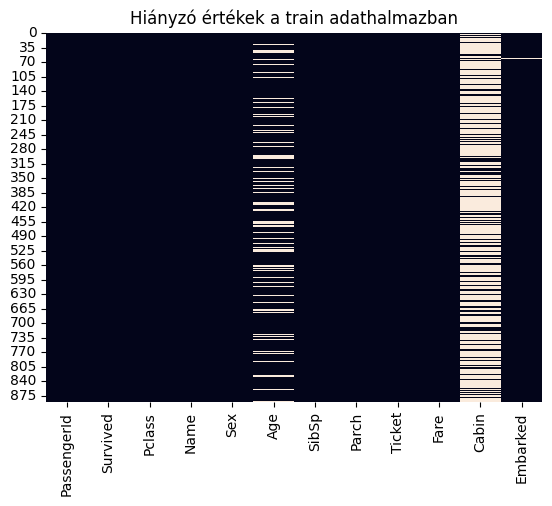

In [9]:
sb.heatmap(train.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train adathalmazban')
plt.show()

In [10]:
train_new = train.copy()

In [11]:
train_new['Age'] = train_new['Age'].fillna(train_new['Age'].median())

In [12]:
print(train_new['Embarked'].mode())

embarked_mode = train_new['Embarked'].mode()[0]
print(embarked_mode)

train_new['Embarked'] = train_new['Embarked'].fillna(embarked_mode)

0    S
Name: Embarked, dtype: object
S


In [13]:
train_new = train_new.drop(columns=['Cabin'])
train_new = train_new.drop(columns=['PassengerId'])
train_new = train_new.drop(columns=['Ticket'])

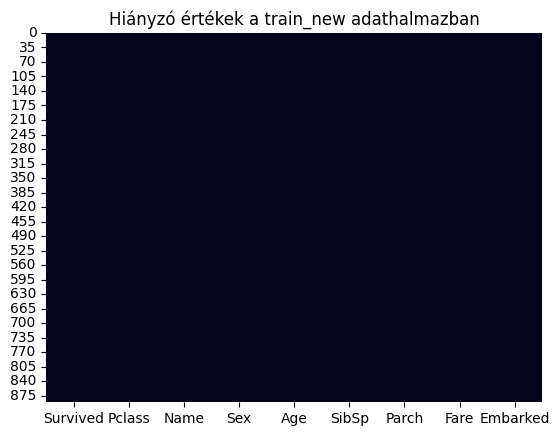

In [14]:
sb.heatmap(train_new.isnull(), linecolor= "white", cbar=False)
plt.title('Hiányzó értékek a train_new adathalmazban')
plt.show()

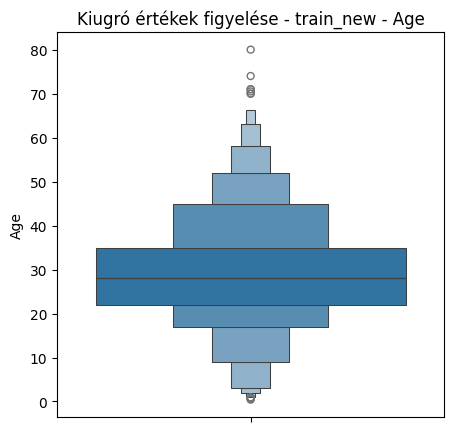

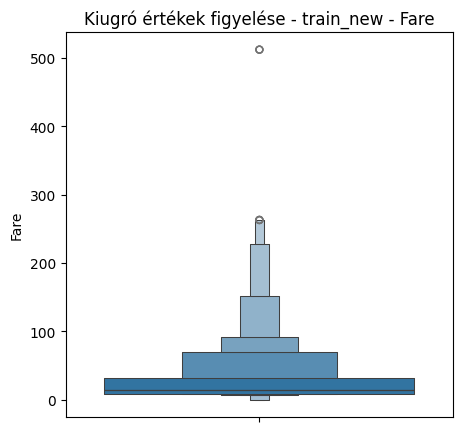

In [15]:
for col in ['Age', 'Fare']:
    plt.figure(figsize=(5,5))
    sb.boxenplot(y=train_new[col])
    plt.title(f'Kiugró értékek figyelése - train_new - {col}')
    plt.show()

## Feature engineering

In [16]:
train_new['FamilySize'] = train_new['SibSp'] + train_new['Parch'] + 1

print(train_new['FamilySize'].unique())

[ 2  1  5  3  7  6  4  8 11]


In [17]:
train_new['IsAlone'] = (train_new['FamilySize'] == 1).astype(int)

print(train_new['IsAlone'].unique())

[0 1]


In [18]:
train_new['Title'] = train_new['Name'].str.extract(r', (\w+)\.')[0]

print(train_new['Title'].unique())

['Mr' 'Mrs' 'Miss' 'Master' 'Don' 'Rev' 'Dr' 'Mme' 'Ms' 'Major' 'Lady'
 'Sir' 'Mlle' 'Col' 'Capt' nan 'Jonkheer']


In [19]:
title_counts = train_new['Title'].value_counts()
rare_titles = title_counts[title_counts < 30].index
train_new['Title'] = train_new['Title'].replace(rare_titles, 'Rare')

In [20]:
print(train_new['Title'].unique())
print(train_new['Title'].isna().sum())

['Mr' 'Mrs' 'Miss' 'Master' 'Rare' nan]
1


In [21]:
train_new['Title'] = train_new['Title'].fillna(train_new['Title'].mode()[0])

In [22]:
train_new = pd.get_dummies(train_new, columns=['Title'], drop_first=False, dtype=int)

In [23]:
train_new = train_new.drop(columns=['Name'])

In [24]:
train_new = pd.get_dummies(train_new, columns=['Embarked'], drop_first=False, dtype=int)

In [25]:
train_new['Sex'] = train_new['Sex'].map({'male': 0, 'female': 1})

In [26]:
print(train_new.columns)

Index(['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
       'FamilySize', 'IsAlone', 'Title_Master', 'Title_Miss', 'Title_Mr',
       'Title_Mrs', 'Title_Rare', 'Embarked_C', 'Embarked_Q', 'Embarked_S'],
      dtype='object')


In [27]:
print(train_new.head())

   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    0  22.0      1      0   7.2500           2        0   
1         1       1    1  38.0      1      0  71.2833           2        0   
2         1       3    1  26.0      0      0   7.9250           1        1   
3         1       1    1  35.0      1      0  53.1000           2        0   
4         0       3    0  35.0      0      0   8.0500           1        1   

   Title_Master  Title_Miss  Title_Mr  Title_Mrs  Title_Rare  Embarked_C  \
0             0           0         1          0           0           0   
1             0           0         0          1           0           1   
2             0           1         0          0           0           0   
3             0           0         0          1           0           0   
4             0           0         1          0           0           0   

   Embarked_Q  Embarked_S  
0           0           1  
1           0     

## Standardizálás

In [28]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
continuous_features = ['Age', 'Fare']

train_new[continuous_features] = scaler.fit_transform(train_new[continuous_features])

In [29]:
train_new.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,FamilySize,IsAlone,Title_Master,Title_Miss,Title_Mr,Title_Mrs,Title_Rare,Embarked_C,Embarked_Q,Embarked_S
0,0,3,0,-0.565736,1,0,-0.502445,2,0,0,0,1,0,0,0,0,1
1,1,1,1,0.663861,1,0,0.786845,2,0,0,0,0,1,0,1,0,0
2,1,3,1,-0.258337,0,0,-0.488854,1,1,0,1,0,0,0,0,0,1
3,1,1,1,0.433312,1,0,0.420730,2,0,0,0,0,1,0,0,0,1
4,0,3,0,0.433312,0,0,-0.486337,1,1,0,0,1,0,0,0,0,1


## Adatok szétválasztása

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
x_train = train_new.drop('Survived', axis=1)
y_train = train_new['Survived']

In [32]:
x_train, x_valtest, y_train, y_valtest = train_test_split(
    x_train, y_train, test_size=0.3, random_state=22, stratify=y_train
)

x_val, x_test, y_val, y_test = train_test_split(
    x_valtest, y_valtest, test_size=0.5, random_state=22, stratify=y_valtest
)

## Modell - Baseline Modell

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report

In [34]:
baseline_model = LogisticRegression(max_iter=500, random_state=42)

In [35]:
baseline_model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,500
,multi_class,'deprecated'


In [37]:
baseline_preds = baseline_model.predict(x_val)

In [39]:
baseline_acc = accuracy_score(y_val, baseline_preds)
baseline_f1 = f1_score(y_val, baseline_preds)

In [41]:
print(f"Baseline Accuracy: {baseline_acc}")
print(f"Baseline F1-score: {baseline_f1}")

Baseline Accuracy: 0.8208955223880597
Baseline F1-score: 0.76


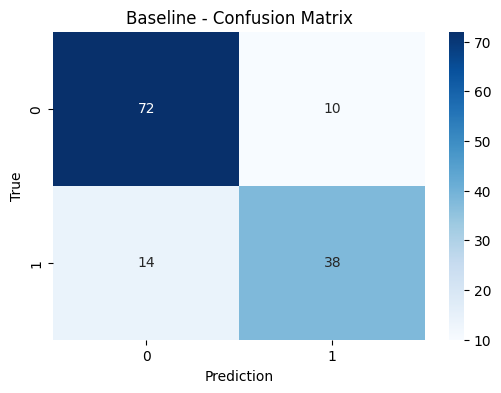

In [45]:
plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_val, baseline_preds), annot=True, fmt='d', cmap='Blues')
plt.title('Baseline - Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('True')
plt.show()

## Modell - Neurális háló

In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.regularizers import l2

In [48]:
print(x_train.shape)
print(x_train.shape[1])

(623, 16)
16


In [49]:
input_dim = x_train.shape[1]

In [50]:
model = Sequential([
    Dense(16, activation='relu', input_shape=[input_dim]),
    Dense(8, activation='relu'),
    Dense(4, activation='relu'),
    Dense(1, activation='sigmoid')
])

c:\Users\User\Desktop\neuhalo\X49HPQ_gepitanulas_beadando_2025\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [51]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=5e-4), 
    loss='binary_crossentropy', 
    metrics=['accuracy']
)

In [52]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 4)              │            36 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             5 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 449 (1.75 KB)

 Trainable params: 449 (1.75 KB)

 Non-trainable params: 0 (0.00 B)

In [53]:
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=10, 
    restore_best_weights=True
)

In [54]:
print(x_train.dtypes)

Pclass            int64
Sex               int64
Age             float64
SibSp             int64
Parch             int64
Fare            float64
FamilySize        int64
IsAlone           int64
Title_Master      int64
Title_Miss        int64
Title_Mr          int64
Title_Mrs         int64
Title_Rare        int64
Embarked_C        int64
Embarked_Q        int64
Embarked_S        int64
dtype: object


In [55]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6308 - loss: 0.6775 - val_accuracy: 0.6194 - val_loss: 0.6922
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6324 - loss: 0.6623 - val_accuracy: 0.6269 - val_loss: 0.6759
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6437 - loss: 0.6490 - val_accuracy: 0.6418 - val_loss: 0.6620
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6485 - loss: 0.6374 - val_accuracy: 0.6418 - val_loss: 0.6482
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6629 - loss: 0.6254 - val_accuracy: 0.6418 - val_loss: 0.6337
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6677 - loss: 0.6135 - val_accuracy: 0.6716 - val_loss: 0.6209
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6742 - loss: 0.6020 - val_accuracy: 0.6791 - val_loss: 0.6096
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6838 - loss: 0.5912 - val_accuracy: 0.6791 - v

## Loss és Validation Accuracy

In [56]:
loss, accuracy = model.evaluate(x_val, y_val, verbose=0)
print(f"Validation accuracy: {accuracy*100:.2f}%")

Validation accuracy: 82.09%


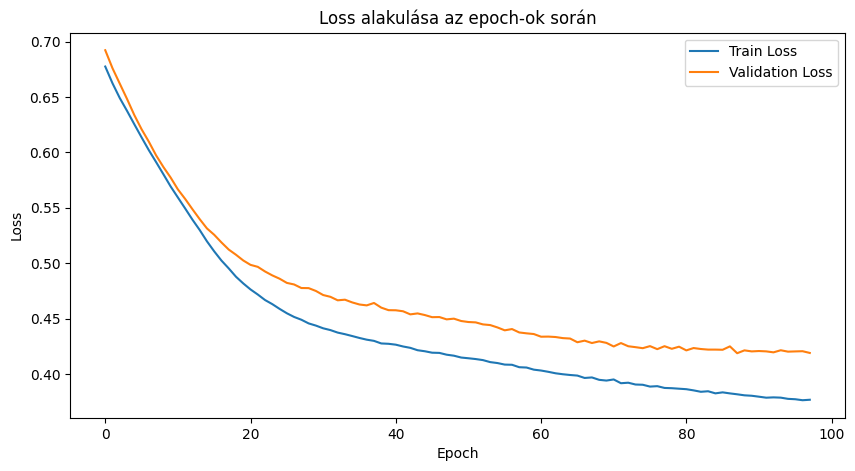

In [57]:
plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss alakulása az epoch-ok során')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

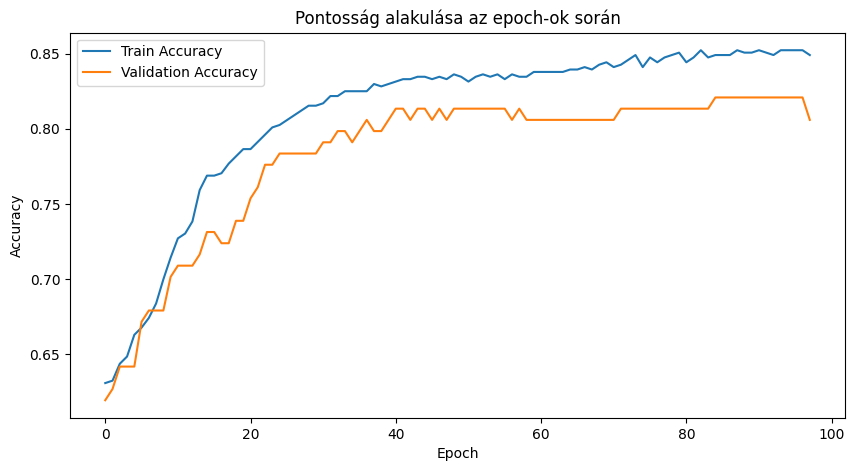

In [58]:
plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Pontosság alakulása az epoch-ok során')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## Confusion matrix 

In [59]:
import numpy as np

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


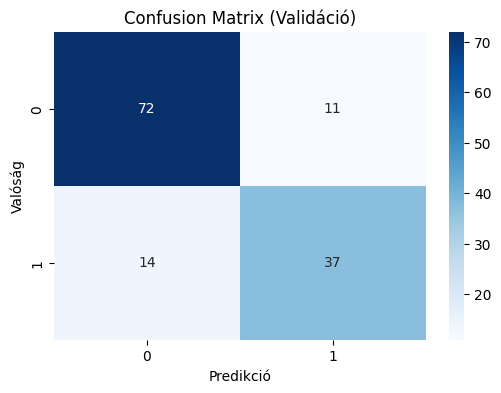

In [61]:
y_pred_test = (model.predict(x_test) > 0.5).astype(int).ravel()

plt.figure(figsize=(6,4))
sb.heatmap(confusion_matrix(y_test, y_pred_test), annot=True, cmap='Blues')
plt.title('Confusion Matrix (Validáció)')
plt.xlabel('Predikció')
plt.ylabel('Valóság')
plt.show()

In [62]:
print("Test accuracy:", accuracy_score(y_test, y_pred_test))

Test accuracy: 0.8134328358208955


## ROC görbe

In [63]:
from sklearn.metrics import roc_curve, roc_auc_score

In [64]:
y_prob_keras = model.predict(x_test).ravel()

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


In [65]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob_keras)

In [66]:
auc_score = roc_auc_score(y_test, y_prob_keras)
print(f"ROC AUC: {auc_score:.3f}")

ROC AUC: 0.867


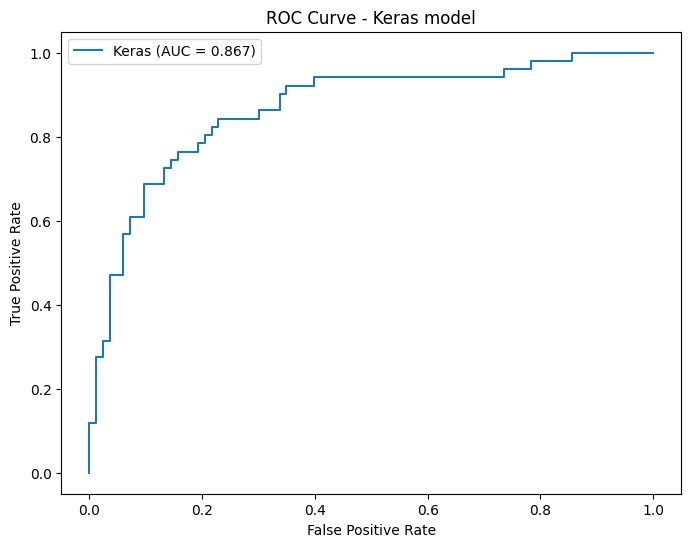

In [67]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"Keras (AUC = {auc_score:.3f})")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Keras model")
plt.legend()
plt.show()

## F1-score

In [68]:
y_val_pred_nn = (model.predict(x_val) > 0.5).astype(int).ravel()
nn_f1 = f1_score(y_val, y_val_pred_nn)
nn_acc = accuracy_score(y_val, y_val_pred_nn)

print(f"Neural Network F1-score: {nn_f1}")

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
Neural Network F1-score: 0.75


## Results

In [69]:
results = pd.DataFrame({
    'Modell': ['Logistic Regression (Baseline)', 'Neural Network'],
    'Accuracy': [baseline_acc, nn_acc],
    'F1-score': [baseline_f1, nn_f1]
})

print(results)

                           Modell  Accuracy  F1-score
0  Logistic Regression (Baseline)  0.820896      0.76
1                  Neural Network  0.820896      0.75
